In [2]:
import pandas as pd

file = "IPL sample data.xlsx"

# Read file without header
temp = pd.read_excel(file, header=None)

# Find the row containing 'Player Name'
header_row = None
for i in range(len(temp)):
    if "Player Name" in temp.iloc[i].astype(str).values:
        header_row = i
        break

print("Header row =", header_row)

# Read again using detected header
df = pd.read_excel(file, header=header_row)

# Clean column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

# # Read data (change skiprows if your data starts on another row)
# df = pd.read_excel(file_path, skiprows=5)

# # Remove unwanted spaces from column names
# df.columns = df.columns.str.strip()

# ==========================
# Weights (Edit these if provided)
# ==========================
WCP = 1      # Clean Pick
WGT = 1      # Good Throw
WC = 2       # Catch
WDC = -2     # Dropped Catch
WST = 2      # Stumping
WRO = 3      # Run Out
WMRO = -2    # Missed Run Out
WDH = 2      # Direct Hit

# ==========================
# Create Indicator Columns
# ==========================

# Pick Column
df['CP'] = (df['Pick'] == 'Y').astype(int)
df['C'] = (df['Pick'] == 'C').astype(int)
df['DC'] = (df['Pick'] == 'DC').astype(int)
df['ST'] = (df['Pick'] == 'S').astype(int)

# Throw Column
df['GT'] = (df['Throw'] == 'Y').astype(int)
df['RO'] = (df['Throw'] == 'RO').astype(int)
df['MRO'] = (df['Throw'] == 'MR').astype(int)
df['DH'] = (df['Throw'] == 'DH').astype(int)

# Runs Saved
df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce').fillna(0)

# ==========================
# Performance Score
# ==========================

df['Performance Score'] = (
    df['CP'] * WCP +
    df['GT'] * WGT +
    df['C'] * WC +
    df['DC'] * WDC +
    df['ST'] * WST +
    df['RO'] * WRO +
    df['MRO'] * WMRO +
    df['DH'] * WDH +
    df['Runs']
)

# ==========================
# Player-wise Summary
# ==========================

summary = df.groupby('Player Name').agg(
    Clean_Picks=('CP', 'sum'),
    Good_Throws=('GT', 'sum'),
    Catches=('C', 'sum'),
    Dropped_Catches=('DC', 'sum'),
    Stumpings=('ST', 'sum'),
    Run_Outs=('RO', 'sum'),
    Missed_Run_Outs=('MRO', 'sum'),
    Direct_Hits=('DH', 'sum'),
    Runs_Saved=('Runs', 'sum'),
    Performance_Score=('Performance Score', 'sum')
).reset_index()

summary = summary.sort_values(
    by='Performance_Score',
    ascending=False
)

print(summary)

# ==========================
# Save Results
# ==========================

with pd.ExcelWriter("Fielding_Performance_Report.xlsx") as writer:
    df.to_excel(writer, sheet_name="Ball by Ball", index=False)
    summary.to_excel(writer, sheet_name="Player Summary", index=False)

print("Report saved as Fielding_Performance_Report.xlsx")

Header row = 4
['Unnamed: 0', 'Match No.', 'Innings', 'Teams', 'Player Name', 'BallCount', 'Position', 'Pick', 'Throw', 'Runs', 'Overcount', 'Venue', 'Stadium']
      Player Name  Clean_Picks  Good_Throws  Catches  Dropped_Catches  \
1               1            0            0        0                0   
7     Lalit yadav            2            1        0                0   
6   Kuldeep yadav            2            1        0                0   
10     Yash Dhull            1            1        0                0   
8       Phil Salt            1            1        0                0   
4      Axer Patel            1            1        0                0   
3       Aman Khan            1            1        0                0   
9   Rilee russouw            0            0        0                0   
0               0            0            0        0                0   
2               2            0            0        0                0   
5     Catches (C)            0      

In [3]:
summary = summary.reset_index()

In [4]:
# ============================================
# Advanced Fielding Analysis
# ============================================

print("\n========== ADVANCED FIELDING ANALYSIS ==========\n")

for _, row in summary.iterrows():

    print(f"\nPlayer: {row['Player Name']}")
    print("-" * 50)

    # Performance Score
    print(f"Performance Score : {row['Performance_Score']}")
    print(f"Runs Saved        : {row['Runs_Saved']}")
    print(f"Catches           : {row['Catches']}")
    print(f"Run Outs          : {row['Run_Outs']}")
    print(f"Direct Hits       : {row['Direct_Hits']}")

    strengths = []
    improvements = []

    # Strengths
    if row['Performance_Score'] >= summary['Performance_Score'].mean():
        strengths.append("Excellent overall fielding performance")

    if row['Runs_Saved'] > 0:
        strengths.append("Saved valuable runs")

    if row['Catches'] > 0:
        strengths.append("Reliable catching ability")

    if row['Run_Outs'] > 0:
        strengths.append("Successfully completed run-outs")

    if row['Direct_Hits'] > 0:
        strengths.append("Accurate direct-hit throws")

    if row['Good_Throws'] > 0:
        strengths.append("Consistent throwing accuracy")

    # Areas for Improvement
    if row['Dropped_Catches'] > 0:
        improvements.append("Reduce dropped catches")

    if row['Missed_Run_Outs'] > 0:
        improvements.append("Improve run-out conversion")

    if row['Runs_Saved'] < 0:
        improvements.append("Reduce runs conceded")

    if row['Good_Throws'] == 0:
        improvements.append("Improve throwing accuracy")

    if len(strengths) == 0:
        strengths.append("Needs improvement in overall fielding")

    if len(improvements) == 0:
        improvements.append("Maintain current performance level")

    print("\nStrengths")
    for s in strengths:
        print("✔", s)

    print("\nAreas for Improvement")
    for i in improvements:
        print("•", i)


========== ADVANCED FIELDING ANALYSIS ==========


Player: 1
--------------------------------------------------
Performance Score : 3.0
Runs Saved        : 3.0
Catches           : 0
Run Outs          : 0
Direct Hits       : 0

Strengths
✔ Excellent overall fielding performance
✔ Saved valuable runs

Areas for Improvement
• Improve throwing accuracy

Player: Lalit yadav
--------------------------------------------------
Performance Score : 3.0
Runs Saved        : 0.0
Catches           : 0
Run Outs          : 0
Direct Hits       : 0

Strengths
✔ Excellent overall fielding performance
✔ Consistent throwing accuracy

Areas for Improvement
• Maintain current performance level

Player: Kuldeep yadav
--------------------------------------------------
Performance Score : 3.0
Runs Saved        : 0.0
Catches           : 0
Run Outs          : 0
Direct Hits       : 0

Strengths
✔ Excellent overall fielding performance
✔ Consistent throwing accuracy

Areas for Improvement
• Maintain current perfor

In [5]:
analysis = []

for _, row in summary.iterrows():

    strengths = []
    improvements = []

    if row['Performance_Score'] >= summary['Performance_Score'].mean():
        strengths.append("Excellent overall fielding")

    if row['Runs_Saved'] > 0:
        strengths.append("Saved valuable runs")

    if row['Catches'] > 0:
        strengths.append("Reliable catching")

    if row['Run_Outs'] > 0:
        strengths.append("Effective run-outs")

    if row['Direct_Hits'] > 0:
        strengths.append("Accurate direct hits")

    if row['Dropped_Catches'] > 0:
        improvements.append("Reduce dropped catches")

    if row['Missed_Run_Outs'] > 0:
        improvements.append("Improve run-out accuracy")

    if row['Runs_Saved'] < 0:
        improvements.append("Reduce runs conceded")

    if len(improvements) == 0:
        improvements.append("Maintain current performance")

    analysis.append({
        "Player Name": row["Player Name"],
        "Performance Score": row["Performance_Score"],
        "Strengths": ", ".join(strengths),
        "Areas for Improvement": ", ".join(improvements)
    })

analysis_df = pd.DataFrame(analysis)

with pd.ExcelWriter("Advanced_Fielding_Analysis.xlsx") as writer:
    summary.to_excel(writer, sheet_name="Player Summary", index=False)
    analysis_df.to_excel(writer, sheet_name="Analysis", index=False)

print("Advanced_Fielding_Analysis.xlsx created successfully!")

Advanced_Fielding_Analysis.xlsx created successfully!


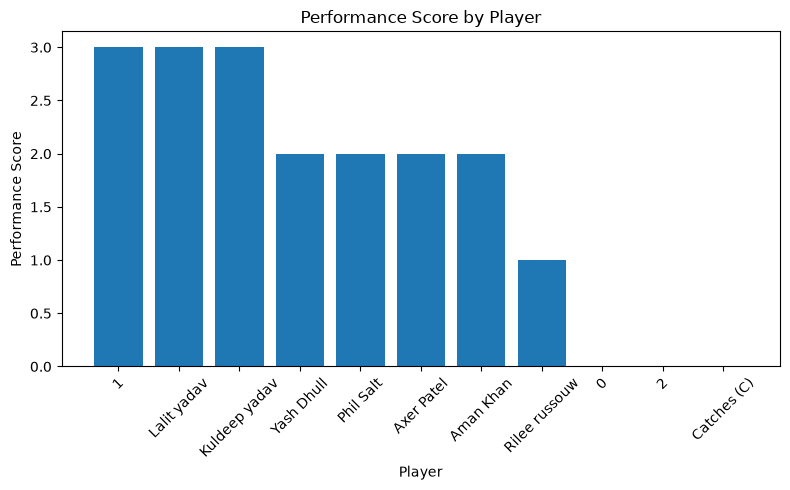

In [6]:
import matplotlib.pyplot as plt

players = summary["Player Name"].astype(str).tolist()
scores = summary["Performance_Score"].astype(float).tolist()

plt.figure(figsize=(8,5))
plt.bar(players, scores)
plt.title("Performance Score by Player")
plt.xlabel("Player")
plt.ylabel("Performance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()